# Treinando nossa primeira rede neural com Keras
Vamos treinar uma rede neural para resolver o problema IRIS

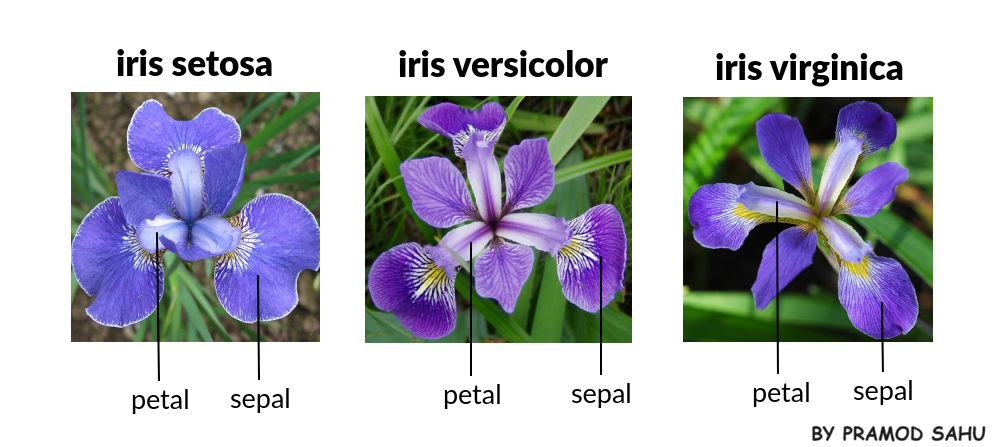

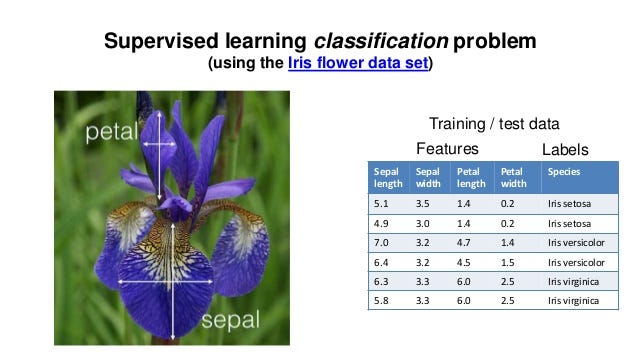

Link da base de dados: https://archive.ics.uci.edu/dataset/53/iris

,sepal-length,sepal-width,petal-length,petal-width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [17]:
iris_df.describe()

,sepal-length,sepal-width,petal-length,petal-width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [19]:
iris_df['class'].value_counts()

,count
class,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


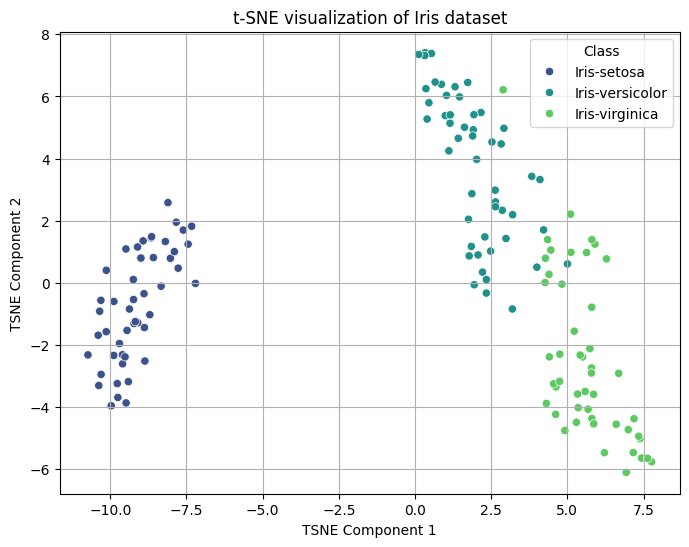

In [144]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)

# Fit and transform the data
X_tsne = tsne.fit_transform(X)

# Create a DataFrame for the t-SNE results and add the class labels
tsne_df = pd.DataFrame(data=X_tsne, columns=['TSNE Component 1', 'TSNE Component 2'])
tsne_df['class'] = y

# Plot the t-SNE results
plt.figure(figsize=(8, 6))
sns.scatterplot(x='TSNE Component 1', y='TSNE Component 2', hue='class', data=tsne_df, palette='viridis')
plt.title('t-SNE visualization of Iris dataset')
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.legend(title='Class')
plt.grid(True)
plt.show()

## Organizar a base Iris treino e teste


In [31]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = iris_df.drop('class', axis=1)
y = iris_df['class']

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12, stratify=y)

# Display the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (120, 4)
Shape of X_test: (30, 4)
Shape of y_train: (120,)
Shape of y_test: (30,)


In [35]:
y_train

,class
8,Iris-setosa
106,Iris-virginica
76,Iris-versicolor
9,Iris-setosa
89,Iris-versicolor
...,...
37,Iris-setosa
2,Iris-setosa
33,Iris-setosa
52,Iris-versicolor


## Ajustando a target para one-hot encoding

In [37]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode the target variable to numerical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Convert numerical labels to one-hot encoding
y_categorical = to_categorical(y_encoded)

# Display the shape of the one-hot encoded target variable
print("Shape of y after one-hot encoding:", y_categorical.shape)
display(y_categorical[:5]) # Display the first 5 rows of the one-hot encoded data

Shape of y after one-hot encoding: (150, 3)


array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [40]:
y_encoded

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Separate features (X) and target (y) - using the original iris_df
X = iris_df.drop('class', axis=1)
y = iris_df['class']

# Encode the target variable to numerical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Convert numerical labels to one-hot encoding
y_categorical = to_categorical(y_encoded)

# Split the dataset into training and testing sets (80% train, 20% test) with the one-hot encoded y
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42+1, stratify=y_encoded) # Stratify using the encoded labels

# Display the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (120, 4)
Shape of X_test: (30, 4)
Shape of y_train: (120, 3)
Shape of y_test: (30, 3)


# Crando uma MLP

MLP 4 neuronios (entrada), 3 camanda escondida e 3 camanda de saída.

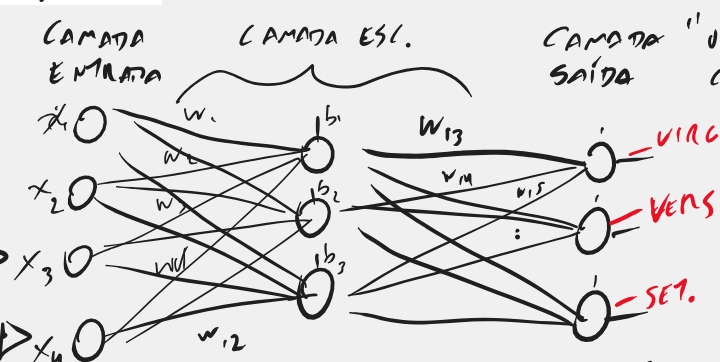

In [97]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create the Sequential model
model = Sequential([
    # Input layer with 4 neurons
    Dense(3, input_shape=(4,), activation='tanh'),
    # Output layer with 3 neurons (for the 3 classes)
    Dense(3, activation='softmax') # Use softmax for multi-class classification output
])



In [98]:
model.layers[1].get_weights()

[array([[ 0.48596764,  0.0903244 , -0.5553076 ],
        [-0.75981855,  0.91820216, -0.692816  ],
        [ 0.5774658 , -0.7473242 , -0.84151816]], dtype=float32),
 array([0., 0., 0.], dtype=float32)]

In [99]:
# Display the model summary
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

## Treinando a rede neural

In [57]:
from keras.optimizers import SGD

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.2015 - loss: 1.4718 - val_accuracy: 0.2000 - val_loss: 1.4289
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2156 - loss: 1.4741 - val_accuracy: 0.2000 - val_loss: 1.4055
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1855 - loss: 1.4147 - val_accuracy: 0.2000 - val_loss: 1.3840
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2130 - loss: 1.3411 - val_accuracy: 0.1667 - val_loss: 1.3645
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1939 - loss: 1.4476 - val_accuracy: 0.1667 - val_loss: 1.3470
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2520 - loss: 1.3712 - val_accuracy: 0.2000 - val_loss: 1.3314
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2395 - loss: 1.3486 - val_accuracy: 0.2667 - val_loss: 1.3175
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2121 - loss: 1.4131 - val_accuracy: 0.3000 - val_loss:

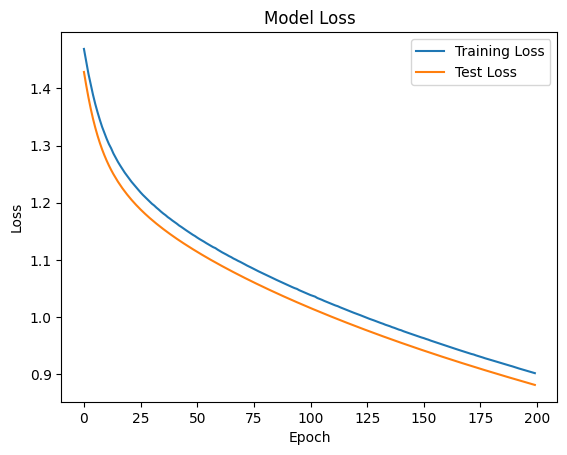

In [93]:
# Compile the model
# mudando o optimizer do 'sgd' para um keras.optimizers.SGD(learning_rate=0.01)
model.compile(optimizer=SGD(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train,
                    epochs=200,
                    batch_size=20,
                    validation_data=(X_test, y_test)
                    )

# Plot the training and validation loss
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

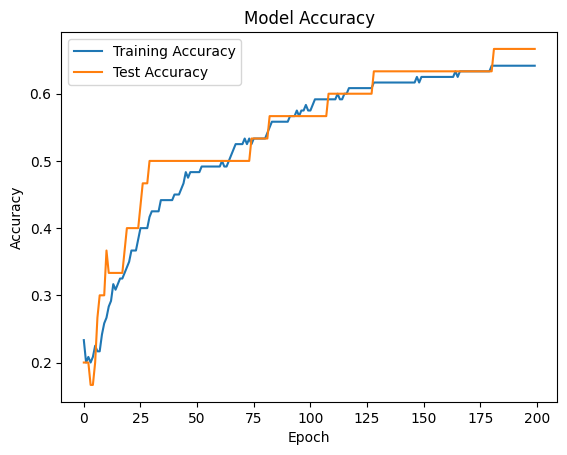

In [94]:
# Plot the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## Treinando uma nova arquitetura 4,4,3,3 MLP

In [129]:


# Create the Sequential model
model = Sequential([
    # Input layer with 4 neurons
    Dense(4, input_shape=(4,), activation='tanh'),
    # mais uma camada escondida
    Dense(3, activation='tanh'),
    # Output layer with 3 neurons (for the 3 classes)
    Dense(3, activation='softmax') # Use softmax for multi-class classification output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [130]:
model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47 (188.00 B)

 Trainable params: 47 (188.00 B)

 Non-trainable params: 0 (0.00 B)

In [131]:
model.layers[0].get_weights()

[array([[ 0.36913687,  0.07605731,  0.24242264,  0.6170173 ],
        [ 0.6094267 , -0.09540558, -0.80128074, -0.5655246 ],
        [ 0.7802575 ,  0.09248024, -0.37340808, -0.85545874],
        [-0.42803082,  0.02856064,  0.6243574 ,  0.11509687]],
       dtype=float32),
 array([0., 0., 0., 0.], dtype=float32)]

Epoch 1/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.3505 - loss: 1.2081 - val_accuracy: 0.3333 - val_loss: 1.2642
Epoch 2/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3565 - loss: 1.2579 - val_accuracy: 0.3333 - val_loss: 1.2613
Epoch 3/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3162 - loss: 1.2498 - val_accuracy: 0.3333 - val_loss: 1.2583
Epoch 4/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3223 - loss: 1.2071 - val_accuracy: 0.3333 - val_loss: 1.2554
Epoch 5/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3380 - loss: 1.2809 - val_accuracy: 0.3333 - val_loss: 1.2526
Epoch 6/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2675 - loss: 1.3076 - val_accuracy: 0.3333 - val_loss: 1.2497
Epoch 7/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2420 - loss: 1.2444 - val_accuracy: 0.3000 - val_loss: 1.2469
Epoch 8/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3226 - loss: 1.2336 - val_accuracy: 0.3000 - val_loss:

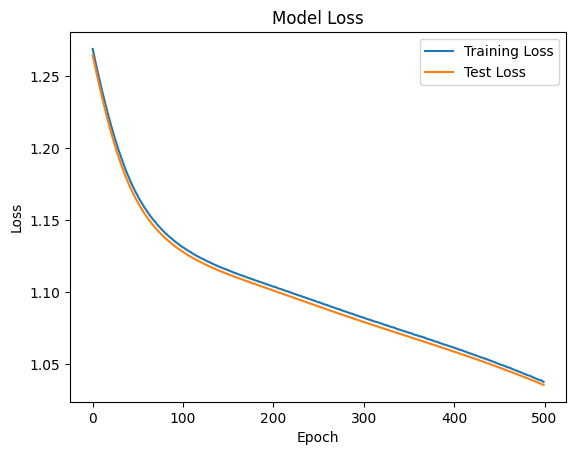

In [132]:
# Compile the model
# mudando o optimizer do 'sgd' para um keras.optimizers.SGD(learning_rate=0.01)
model.compile(optimizer=SGD(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train,
                    epochs=500,
                    batch_size=20,
                    validation_data=(X_test, y_test)
                    )

# Plot the training and validation loss
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

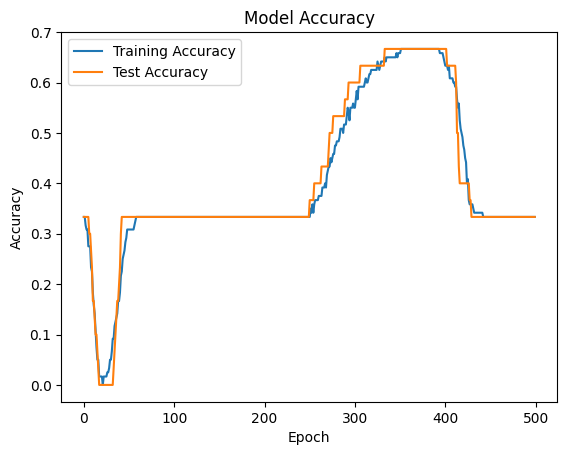

In [133]:
# Plot the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## Realizando um terceiro experimento - MLP mais robusta
Vamos agora treinar uma MLP 4(entrada) 16(escondida 1) 8(escondida 2) 3 (saída)

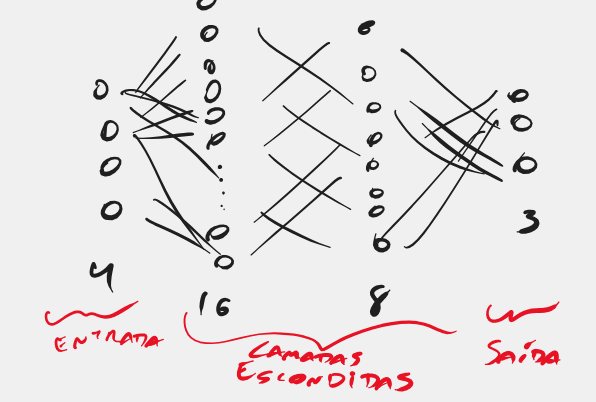

In [140]:
# Create the Sequential model
model = Sequential([
    # Input layer with 4 neurons
    Dense(16, input_shape=(4,), activation='tanh'),
    # mais uma camada escondida
    Dense(8, activation='tanh'),
    # Output layer with 3 neurons (for the 3 classes)
    Dense(3, activation='softmax') # Use softmax for multi-class classification output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [141]:
model.layers[0].get_weights()

[array([[-0.2606063 ,  0.11246854, -0.38184297,  0.39951688, -0.53489524,
         -0.08541462,  0.21285498,  0.17326552, -0.07025906, -0.10525489,
          0.3853684 ,  0.43643206,  0.48243284,  0.45657063, -0.12819383,
          0.10307539],
        [-0.14438534,  0.5190191 , -0.4510038 ,  0.48221517,  0.5237149 ,
         -0.4685636 , -0.0122155 , -0.11222747, -0.5470913 ,  0.2627051 ,
         -0.30238754, -0.42028862, -0.00078303, -0.11236405,  0.08308864,
          0.4897294 ],
        [ 0.47245944, -0.42203707, -0.16255447, -0.05101821,  0.5388311 ,
         -0.31769943, -0.1676479 , -0.47970986,  0.07526851, -0.05712342,
         -0.16988355, -0.38173234,  0.3338464 ,  0.30136895, -0.12848178,
          0.52288187],
        [ 0.42649698, -0.5179614 ,  0.01562583, -0.41602886,  0.51588213,
          0.1623109 , -0.45468152,  0.38215792, -0.27399787, -0.32033455,
         -0.32017303,  0.09418643,  0.13903713, -0.32828063,  0.05164361,
         -0.06696826]], dtype=float32),
 ar

Epoch 1/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.0418 - loss: 1.1321 - val_accuracy: 0.0000e+00 - val_loss: 1.1283
Epoch 2/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0156 - loss: 1.1297 - val_accuracy: 0.0000e+00 - val_loss: 1.1242
Epoch 3/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0281 - loss: 1.1235 - val_accuracy: 0.0333 - val_loss: 1.1203
Epoch 4/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0086 - loss: 1.1240 - val_accuracy: 0.0667 - val_loss: 1.1164
Epoch 5/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0340 - loss: 1.1182 - val_accuracy: 0.0667 - val_loss: 1.1125
Epoch 6/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0251 - loss: 1.1157 - val_accuracy: 0.0667 - val_loss: 1.1087
Epoch 7/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0239 - loss: 1.1136 - val_accuracy: 0.0667 - val_loss: 1.1049
Epoch 8/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0610 - loss: 1.1066 - val_accuracy: 0.0667 - v

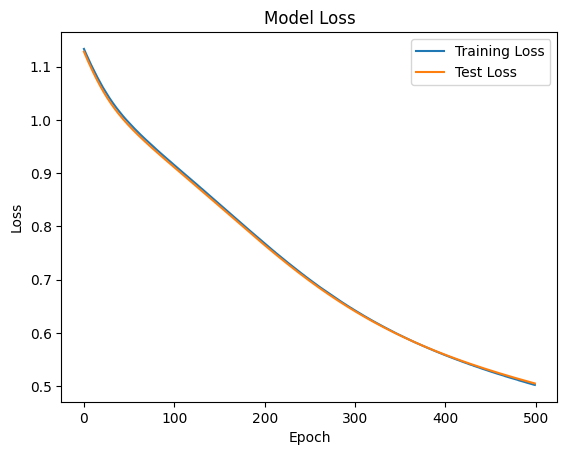

In [142]:
# Compile the model
model.compile(optimizer=SGD(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train,
                    epochs=500,
                    batch_size=20,
                    validation_data=(X_test, y_test)
                    )


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

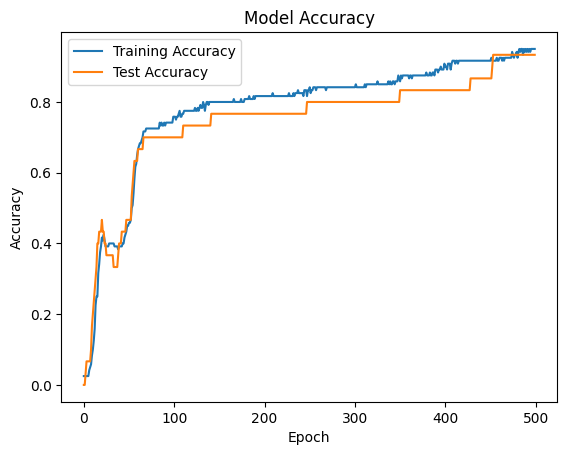

In [143]:
# Plot the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()